In [33]:
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from tavily import TavilyClient
from typing import Literal
import os
load_dotenv()

True

In [34]:
from langchain_google_genai import ChatGoogleGenerativeAI
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
model = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")

In [35]:
tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])
def web_search(query:str, max_results:int = 5, topic: Literal["sports","news","finance"] = "general",include_raw_content:bool = False):
    """Run a web search"""
    return tavily_client.search(query,max_results=max_results,topic=topic,include_raw_content=include_raw_content)

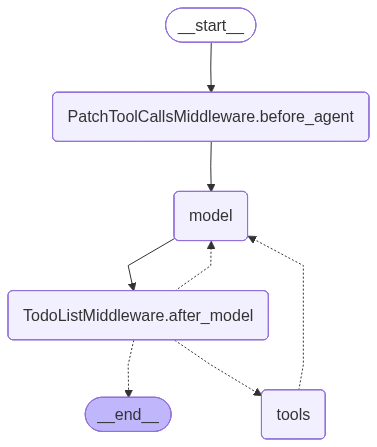

In [ ]:
from deepagents import create_deep_agent
DeepAgent = create_deep_agent(
    model= model,
    tools=[web_search],
    system_prompt="""You are an expert researcher. Your job is to conduct thorough research and then write a polished report.
You have access to an internet search tool as your primary means of gathering information.
Use this to run an internet search for a given query. You can specify the max number of results to return, topic, and whether raw content should be included."""
)
DeepAgent

In [37]:
response = DeepAgent.invoke({"messages":[{"role":"user","content":"What is langgraph?"}]})
response

{'messages': [HumanMessage(content='What is langgraph?', additional_kwargs={}, response_metadata={}, id='09360fcb-7265-4468-8095-61d13976cec1'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'web_search', 'arguments': '{"query": "what is langgraph"}'}, '__gemini_function_call_thought_signatures__': {'b0f8bd1f-7b9b-40a3-9038-1f139e5f5d82': 'EqkFCqYFAb4+9vsfm8RDtfGgTcByp4sudYSg/KM7HYW+k6RKeXmjGw68uNMAkdhbCPBKJaC8Q4SRvblFHzaL3IkN/PDUxNZCjSRzW4ax/GuBJAorbcO9hhfZ6FDCu4q1hf2uMEEy8OKTjCiKecMvWLDr3Dm0GjuPAfbehoDbm3AfhbeGbCLJLPZpxtBPaXezKUMHqoYOqzyTa0kIH1RbQ9pRyy8H69Xj8NRdihNpQt1BiK+P2dqIs1dOh/eWfN9wtFuEsGXzl5pCyk5XGq4xd59IQj0l2X6pm84yaDeHkHJoC/o8Y+M70ipyzs40qv/IpPskqGBUdRRlYg5om9wuxKgHWsYjOfjESpiMiXf6MoP4kIKku0GewlWeE/WGs2iJKoxvciIn+t0akdGqjj7HmMWgtP5DUMe1qU0PeRfZJ9lX170YD2DmUnFgGNzu6yE1HxeqNyUi+q/HLc7gaf9nRPtm2eFkYWD4XSVFMuVoVg8P3EbEtcHG4aeIRG+TwjJgXIKjy5s/f3ZNyKkN+RgIq6hsYOuyC0h1w3kEBFWGDXvnBGeUy5yjM45IXj+zgkL0owNohSygM64a5m5JdgSNmTPtQGRt81RDm5P4XX9iO+xj2MZ9DTgxUfeOmOM